In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import pandas as pd

from neural_reconstruction.algorithms.fragment_linking.linker import HierarchicalFragmentLinker
from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar
from neural_reconstruction.core.crosses_detection import RegionLabeler, SegmentDetector, CrossingCounter

import skimage as ski
# from skimage.measure import label
# from skimage.restoration import rolling_ball
from scipy.spatial import KDTree

from xgboost import XGBClassifier
import joblib


In [2]:
BASE_PATH = Path('/home/pony/projects/ienf_q/')
IMAGE_ID = 'S1585-2_a'
BASE_PATH = BASE_PATH / f'nas/jia/data_0320/{IMAGE_ID}'

In [3]:
image      = cv2.imread(f'{BASE_PATH}/image.png',      cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/mask.png',       cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/weka.png', cv2.IMREAD_GRAYSCALE)

print(f'image      shape: {image.shape},      dtype: {image.dtype}')
print(f'mask       shape: {mask.shape},       dtype: {mask.dtype}')
print(f'annotation shape: {annotation.shape}, dtype: {annotation.dtype}')


image      shape: (2867, 5632),      dtype: uint8
mask       shape: (2867, 5632),       dtype: uint8
annotation shape: (2867, 5632), dtype: uint8


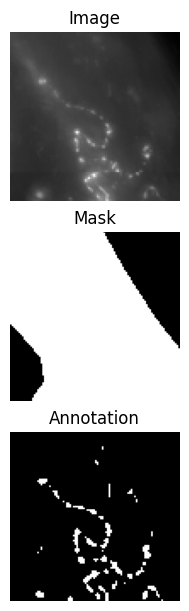

In [4]:
def crop(image:np.ndarray):
    x, y, w, h = 4840, 1760 , 100, 100
    cropped_image = image[y:y+h, x:x+w]
    return cropped_image

roi_image = crop(image)
roi_mask = crop(mask)
roi_annotation = crop(annotation)
_, axes = plt.subplots(3, 1, figsize=(18, 6), constrained_layout=True)
axes[0].imshow(roi_image,      cmap='gray');  axes[0].set_title('Image');       axes[0].axis('off')
axes[1].imshow(roi_mask,       cmap='gray');  axes[1].set_title('Mask');        axes[1].axis('off')
axes[2].imshow(roi_annotation, cmap='gray');  axes[2].set_title('Annotation');  axes[2].axis('off')
plt.show()

In [5]:
builder = TopologyBuilder(segment_length=1.0)
skeleton = builder.build_skeleton_graph(roi_annotation, roi_image)

print(f'Nodes: {skeleton.number_of_nodes()}')
print(f'Edges: {skeleton.number_of_edges()}')
degrees = dict(skeleton.degree())
print(f'Endpoints (degree=1): {sum(1 for d in degrees.values() if d == 1)}')
print(f'Junctions (degree>=3): {sum(1 for d in degrees.values() if d >= 3)}')
print(f'Isolated  (degree=0): {sum(1 for d in degrees.values() if d == 0)}')

Nodes: 71
Edges: 30
Endpoints (degree=1): 60
Junctions (degree>=3): 0
Isolated  (degree=0): 11


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [6]:
def draw_graph_on_image(ax, graph, bg_image, title='', cmap='gray',
                        node_size=6, edge_alpha=0.8, color_by_distance=True):
    """Overlay a skeleton/seed graph on a background image."""
    ax.imshow(bg_image, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

    if graph.number_of_edges() == 0 and graph.number_of_nodes() == 0:
        return

    # --- edges ---
    if color_by_distance and graph.number_of_edges() > 0:
        distances = [d.get('branch-distance', 0) for _, _, d in graph.edges(data=True)]
        vmin, vmax = min(distances), max(distances)
        cmap_edge = plt.cm.plasma
        norm = plt.Normalize(vmin=vmin, vmax=max(vmax, 1e-6))

    for u, v, data in graph.edges(data=True):
        path = data.get('path', [u, v])
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        if color_by_distance:
            color = cmap_edge(norm(data.get('branch-distance', 0)))
        else:
            color = 'cyan'
        ax.plot(xs, ys, color=color, linewidth=1.2, alpha=edge_alpha)

    # --- nodes: coloured by degree ---
    for node in graph.nodes():
        y, x = node
        deg = graph.degree(node)
        if deg == 0:
            color, zorder, size = 'yellow', 4, node_size * 1.5   # isolated
        elif deg == 1:
            color, zorder, size = 'red',    4, node_size          # endpoint
        elif deg == 2:
            color, zorder, size = 'lime',   3, node_size * 0.7   # chain (should be merged)
        else:
            color, zorder, size = 'blue',   5, node_size * 1.4   # junction
        ax.scatter(x, y, c=color, s=size**2, zorder=zorder, linewidths=0)

    # colorbar for edge distance
    if color_by_distance and graph.number_of_edges() > 0:
        sm = plt.cm.ScalarMappable(cmap=cmap_edge, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01, label='branch-distance (px)')

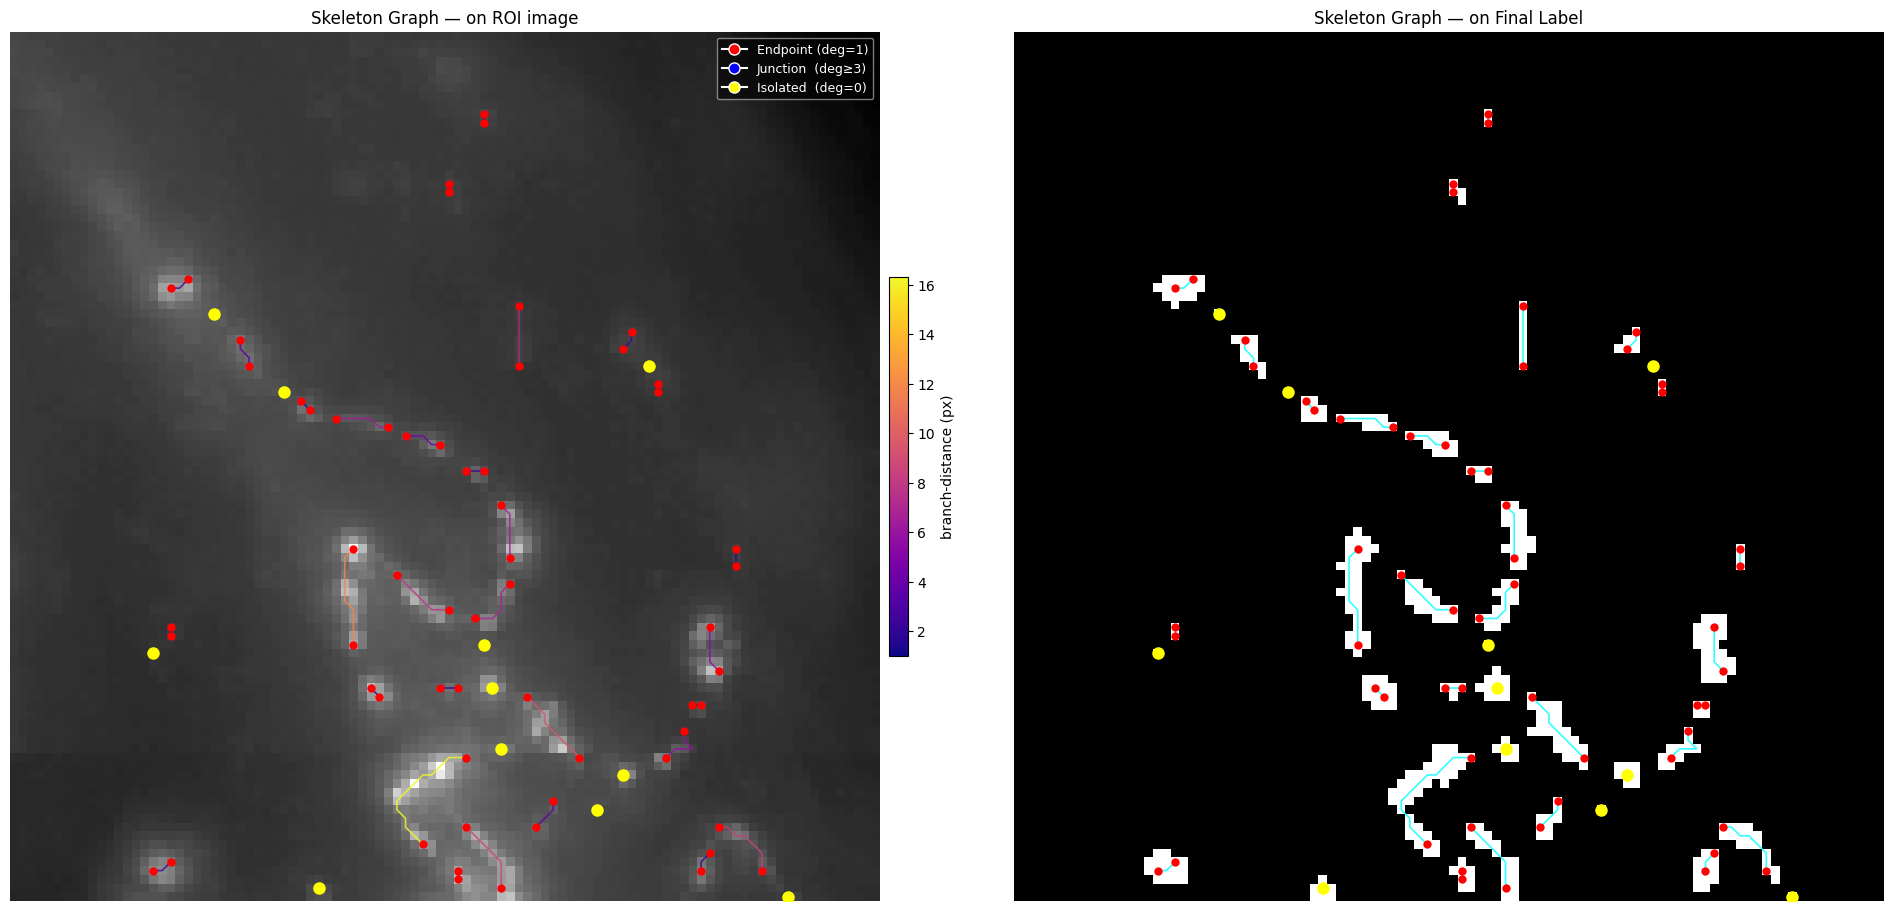

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
draw_graph_on_image(axes[0], skeleton, roi_image,
                    title='Skeleton Graph — on ROI image', color_by_distance=True)
draw_graph_on_image(axes[1], skeleton, roi_annotation,
                    title='Skeleton Graph — on Final Label', color_by_distance=False)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Endpoint (deg=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=8, label='Junction  (deg≥3)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Isolated  (deg=0)'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9,
               framealpha=0.6, facecolor='black', labelcolor='white')
plt.show()

In [8]:
seed = builder.build_seed_graph(roi_annotation , roi_image)

print(f'Skeleton → Seed')
print(f'  Nodes:  {skeleton.number_of_nodes():>5}  →  {seed.number_of_nodes()}')
print(f'  Edges:  {skeleton.number_of_edges():>5}  →  {seed.number_of_edges()}')
degrees = dict(seed.degree())
print(f'Endpoints (degree=1): {sum(1 for d in degrees.values() if d == 1)}')
print(f'Junctions (degree>=3): {sum(1 for d in degrees.values() if d >= 3)}')
print(f'Isolated  (degree=0): {sum(1 for d in degrees.values() if d == 0)}')

Skeleton → Seed
  Nodes:     71  →  148
  Edges:     30  →  107
Endpoints (degree=1): 60
Junctions (degree>=3): 0
Isolated  (degree=0): 11


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [9]:
# cost_map: bright pixels = low cost (prefer nerve fiber tissue)
cost_map = (255 - roi_image.astype(np.float32)) / 255.0
pathfinder = PathFinder(cost_map)

# Extract seed nodes as topology_points array
node_list = list(seed.nodes())
topology_points = np.array(node_list, dtype=np.int32)   # shape (N, 2), each row = (y, x)
kdtree = KDTree(topology_points)

print(f'Cost map shape: {cost_map.shape}, range: [{cost_map.min():.3f}, {cost_map.max():.3f}]')
print(f'Topology points: {len(topology_points)}')

Cost map shape: (100, 100), range: [0.004, 0.890]
Topology points: 148


In [10]:
SEARCH_RADIUS = 40.0

path_lookup = pathfinder.find_paths_from_seeds(
    topology_points=topology_points,
    kdtree=kdtree,
    search_radius=SEARCH_RADIUS,
)

full_connected_graph = seed.copy()
for u, v, data in seed.edges(data=True):
    data['weight'] = 1e-5
for (start, target), (path, cost) in path_lookup.items():
    full_connected_graph.add_edge(start, target, path=path, branch_distance=cost, weight=cost)

mst = nx.minimum_spanning_tree(full_connected_graph, weight='weight')

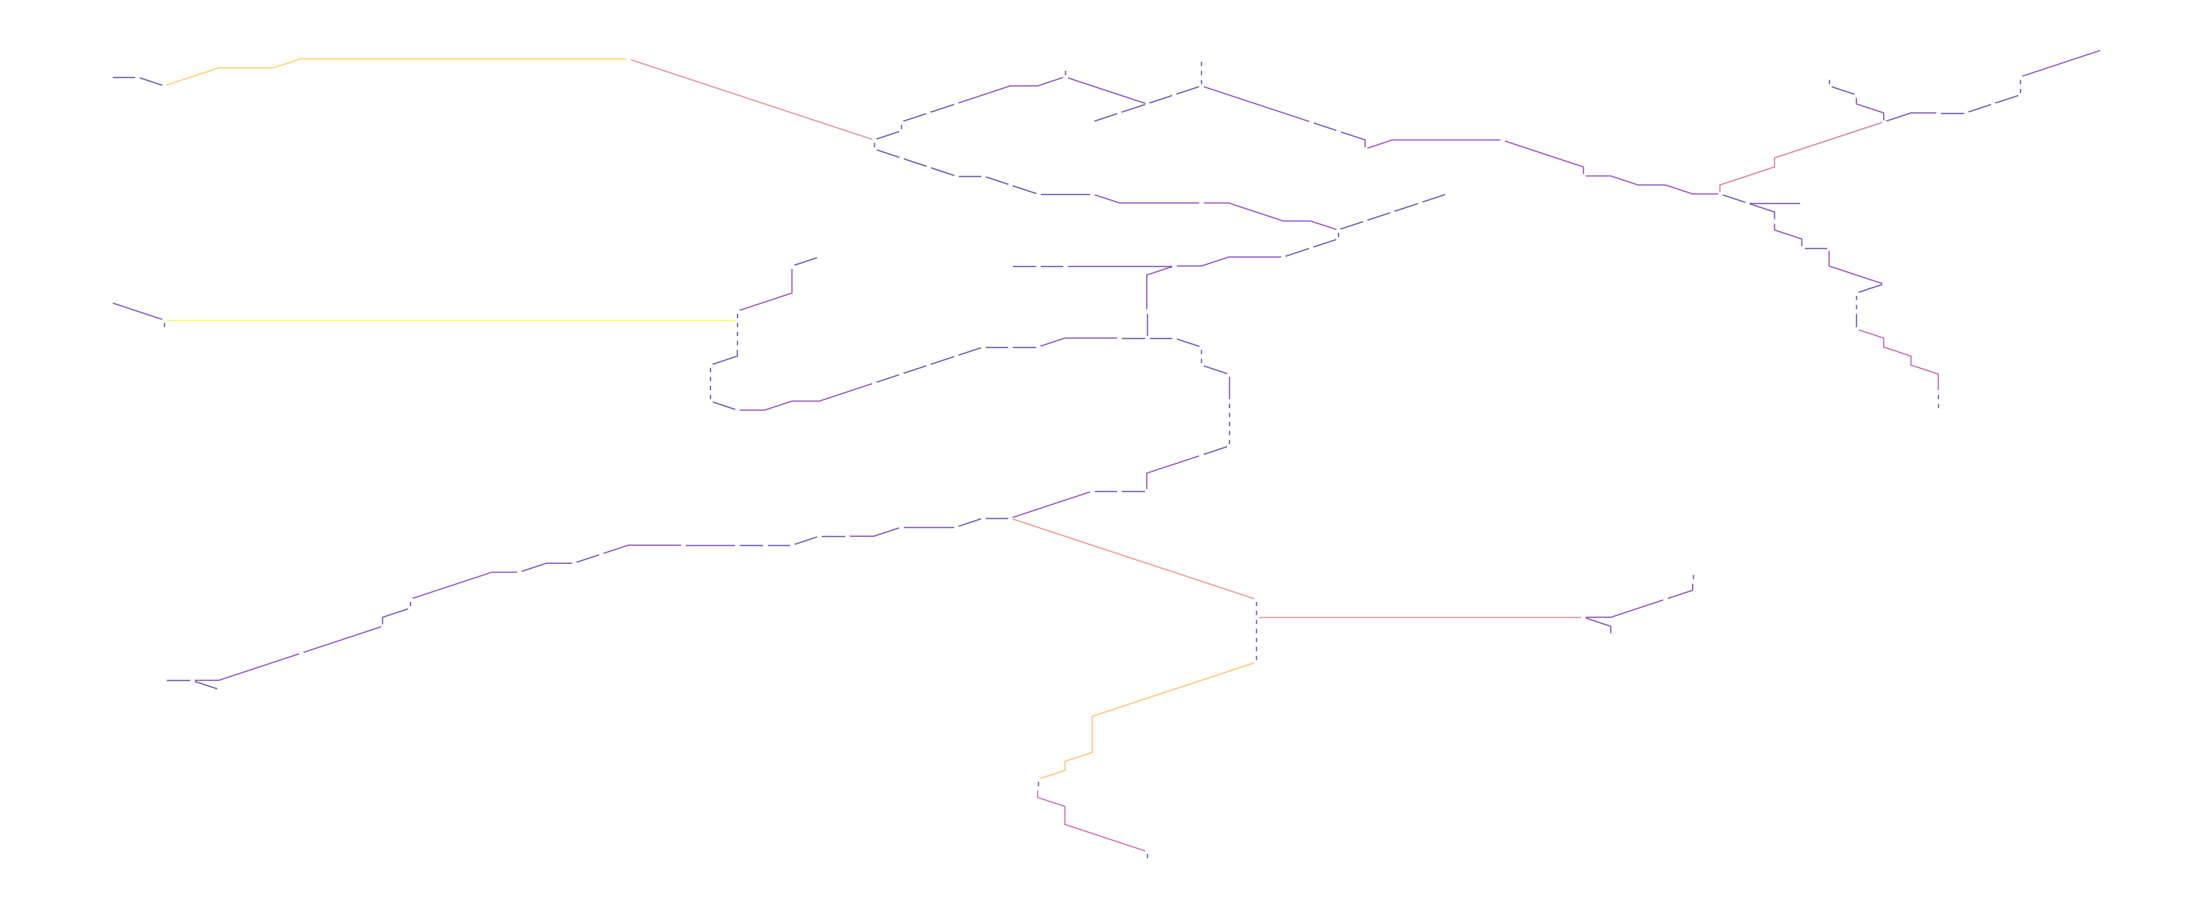

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(22, 9), constrained_layout=True)

all_costs = [v['weight'] for _, _, v in mst.edges(data=True)]
norm_all  = plt.Normalize(vmin=min(all_costs), vmax=max(all_costs))
cmap_all  = plt.cm.plasma

ax.axis('off')

for s, t, data in mst.edges(data=True):

    ys = [p[0] for p in data['path']]
    xs = [p[1] for p in data['path']]
    ax.plot(xs, ys, color=cmap_all(norm_all(data['weight'])), linewidth=1.0, alpha=0.6)

# Seed nodes
ax.scatter(topology_points[:, 1], topology_points[:, 0],
            c='white', s=12, zorder=5, linewidths=0)

sm = plt.cm.ScalarMappable(cmap=cmap_all, norm=norm_all)
sm.set_array([])
plt.colorbar(sm, ax=axes[1], fraction=0.02, pad=0.01, label='Path cost')
plt.show()

In [12]:
segment_detector = SegmentDetector()
segmented_graph = segment_detector.detect_segments(mst)


/tmp/ipykernel_813641/1017028950.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', 20)


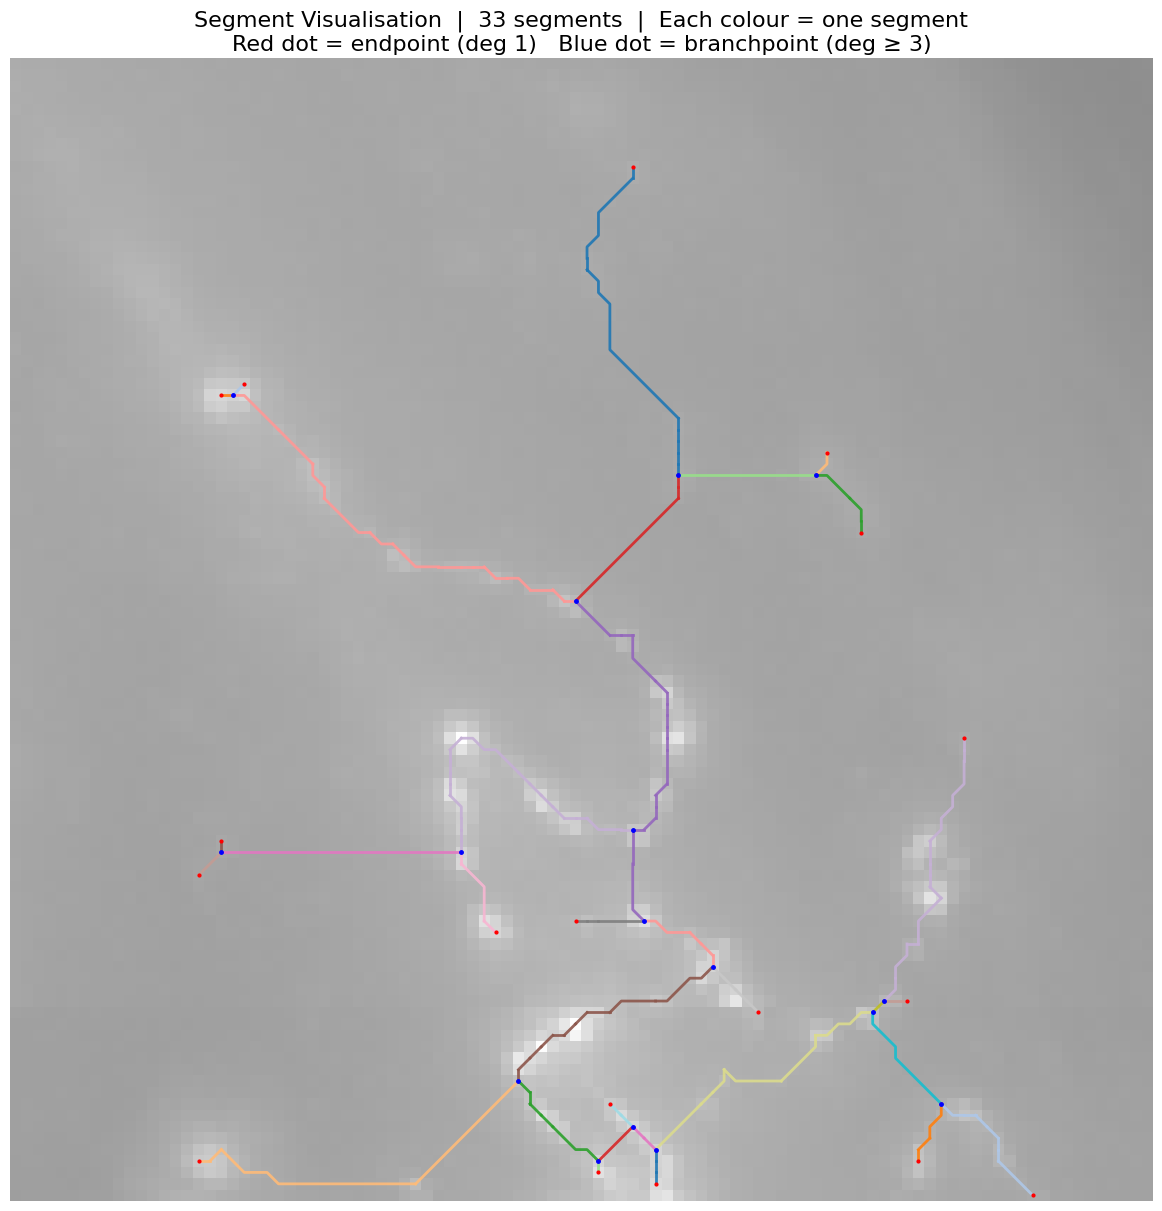

In [13]:
seg_ids = sorted({
    d['segment_id']
    for _, _, d in segmented_graph.edges(data=True)
    if d.get('segment_id') is not None
})

# Build a colour palette that cycles through tab20 so nearby IDs look different
palette = plt.cm.get_cmap('tab20', 20)
seg_color = {sid: palette(i % 20) for i, sid in enumerate(seg_ids)}

fig, ax = plt.subplots(1, 1, figsize=(12,12), constrained_layout=True)

viz = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2RGB)
ax.imshow(viz, alpha=0.5)

# Draw edges coloured by segment_id
for u, v, data in segmented_graph.edges(data=True):
    path = data.get('path', [u, v])
    if len(path) < 2:
        continue
    sid = data.get('segment_id')
    color = seg_color.get(sid, (1, 1, 1, 1))
    ax.plot([p[1] for p in path], [p[0] for p in path],
            color=color, linewidth=2.0, alpha=0.9)

# Draw boundary nodes
for node in segmented_graph.nodes():
    ntype = segmented_graph.nodes[node].get('node_type')
    if ntype == 'endpoint':
        ax.plot(node[1], node[0], 'r.', markersize=4, zorder=5)
    elif ntype == 'branchpoint':
        ax.plot(node[1], node[0], 'b.', markersize=5, zorder=5)

ax.set_title(
    f'Segment Visualisation  |  {len(seg_ids)} segments  |  '
    'Each colour = one segment\n'
    'Red dot = endpoint (deg 1)   Blue dot = branchpoint (deg ≥ 3)',
    fontsize=16,
)
ax.axis('off')
plt.savefig('segment_visualization.png', dpi=72, bbox_inches='tight')
plt.show()

In [14]:
from collections import defaultdict

def _path_length(data, u, v):
    path = data.get('path', [u, v])
    return len(path) - 1  # number of pixel steps

seg_edges = defaultdict(list)
for u, v, data in segmented_graph.edges(data=True):
    seg_id = data.get('segment_id')
    if seg_id is not None:
        seg_edges[seg_id].append((u, v, data))

edges_to_remove = []
for seg_id, edges in seg_edges.items():
    # Collect boundary nodes of this segment
    boundary_nodes = set()
    for u, v, _ in edges:
        if segmented_graph.nodes[u].get('node_type') in ('endpoint', 'branchpoint'):
            boundary_nodes.add(u)
        if segmented_graph.nodes[v].get('node_type') in ('endpoint', 'branchpoint'):
            boundary_nodes.add(v)

    # Only prune if at least one boundary node is an endpoint (dangling stub)
    has_endpoint = any(
        segmented_graph.nodes[n].get('node_type') == 'endpoint'
        for n in boundary_nodes
    )
    if not has_endpoint:
        continue

    total_length = sum(_path_length(data, u, v) for u, v, data in edges)
    if total_length < 5:
        edges_to_remove.extend((u, v) for u, v, _ in edges)

segmented_graph.remove_edges_from(edges_to_remove)
segmented_graph.remove_nodes_from(list(nx.isolates(segmented_graph)))
print(f'Pruned {len(edges_to_remove)} stub edges → '
      f'{segmented_graph.number_of_nodes()} nodes, {segmented_graph.number_of_edges()} edges')

Pruned 16 stub edges → 132 nodes, 131 edges


In [15]:
small_removed_segment = segment_detector.detect_segments(segmented_graph)


/tmp/ipykernel_813641/157631180.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', 20)


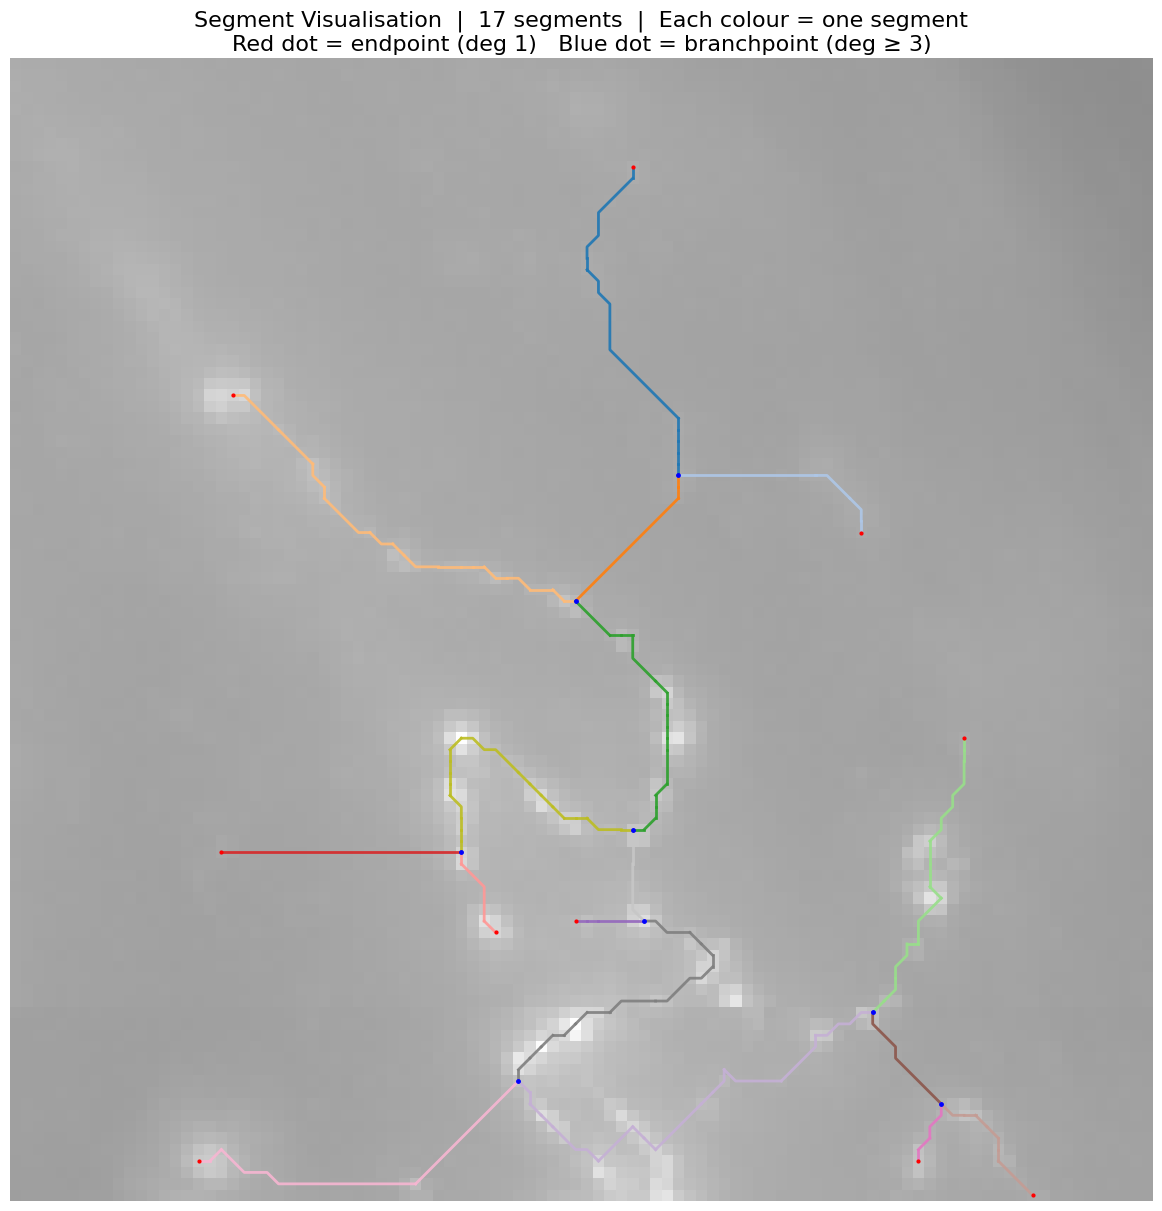

In [16]:
seg_ids = sorted({
    d['segment_id']
    for _, _, d in small_removed_segment.edges(data=True)
    if d.get('segment_id') is not None
})

# Build a colour palette that cycles through tab20 so nearby IDs look different
palette = plt.cm.get_cmap('tab20', 20)
seg_color = {sid: palette(i % 20) for i, sid in enumerate(seg_ids)}

fig, ax = plt.subplots(1, 1, figsize=(12,12), constrained_layout=True)

viz = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2RGB)
ax.imshow(viz, alpha=0.5)

# Draw edges coloured by segment_id
for u, v, data in small_removed_segment.edges(data=True):
    path = data.get('path', [u, v])
    if len(path) < 2:
        continue
    sid = data.get('segment_id')
    color = seg_color.get(sid, (1, 1, 1, 1))
    ax.plot([p[1] for p in path], [p[0] for p in path],
            color=color, linewidth=2.0, alpha=0.9)

# Draw boundary nodes
for node in small_removed_segment.nodes():
    # ntype = small_removed_segment.nodes[node].get('node_type')
    # if ntype == 'endpoint':
    #     ax.plot(node[1], node[0], 'r.', markersize=4, zorder=5)
    # elif ntype == 'branchpoint':
    #     ax.plot(node[1], node[0], 'b.', markersize=5, zorder=5)
    degree = small_removed_segment.degree(node)
    if degree == 1:
        ax.plot(node[1], node[0], 'r.', markersize=4, zorder=5)
    elif degree >= 3:
        ax.plot(node[1], node[0], 'b.', markersize=5, zorder=5)

ax.set_title(
    f'Segment Visualisation  |  {len(seg_ids)} segments  |  '
    'Each colour = one segment\n'
    'Red dot = endpoint (deg 1)   Blue dot = branchpoint (deg ≥ 3)',
    fontsize=16,
)
ax.axis('off')
plt.savefig('segment_visualization.png', dpi=72, bbox_inches='tight')
plt.show()